# Лабораторная работа №4

Анализ системы `M/M/1` с двумя классами заявок и абсолютным приоритетом без прерывания обслуживания.
Предметная область продолжает ЛР2 и ЛР3: рассматривается сервер обработки `RPC`-запросов к *key-value* базе данных.


## Обозначения и параметры

- `λ1` — интенсивность потока высокоприоритетных заявок;
- `λ2` — интенсивность потока низкоприоритетных заявок;
- `μ_eff` — эффективная интенсивность обслуживания;
- `ρ = (λ1 + λ2) / μ_eff` — общая загрузка системы.

Базовые параметры:

- `λ1 = 1.5 qps`
- `λ2 = 2.0 qps`
- `μ_rpc = 30.0 qps`
- `μ_resp = 40.0 qps`
- `T = 3000.0 c`
- `R = 16`
- высокий класс: `system_critical`
- низкий класс: `background_batch`


In [10]:
import json
import heapq
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

BASE_SEED = 42
lambda_high_qps = 1.5
lambda_low_qps = 2.0
mu_rpc_qps = 30.0
mu_resp_qps = 40.0
database_size = 1000
simulation_time_sec = 3000.0
replications = 16
high_class_label = 'system_critical'
low_class_label = 'background_batch'
command_types = ['GET', 'SET', 'DELETE']
command_probabilities = np.array([0.8, 0.15, 0.05])

def ms(seconds: float) -> float:
    return seconds * 1000.0


## Предметная модель из ЛР2 и ЛР3

Как и в прошлых работах, одна заявка — это `RPC`-запрос к *key-value* сервису. Время обслуживания складывается из:

1. приёма и разбора RPC-запроса;
2. выполнения команды `GET / SET / DELETE`;
3. формирования и отправки ответа.

Приоритет влияет только на порядок выбора заявки из очереди: после освобождения сервера сначала выбирается заявка высокого класса.


In [11]:
def generate_execution_time(command: str, db_size: int, rng: np.random.Generator) -> float:
    means = {
        "GET": np.log(db_size) * 0.020,
        "DELETE": np.log(db_size) * 0.024,
        "SET": db_size * 0.00020,
    }
    return float(rng.exponential(means[command]))

def sample_service_time(mu_rpc: float, mu_resp: float, db_size: int, rng: np.random.Generator, service_rate_scale: float = 1.0):
    command = rng.choice(command_types, p=command_probabilities)
    rpc_time = rng.exponential(1.0 / mu_rpc)
    exec_time = generate_execution_time(command, db_size, rng)
    resp_time = rng.exponential(1.0 / mu_resp)
    scale = max(service_rate_scale, 1e-9)
    return float((rpc_time + exec_time + resp_time) / scale), {"command": command}

def estimate_service_moments(mu_rpc: float, mu_resp: float, db_size: int, samples: int = 50_000, seed: int = BASE_SEED, service_rate_scale: float = 1.0) -> dict:
    rng = np.random.default_rng(seed)
    values = np.array([sample_service_time(mu_rpc, mu_resp, db_size, rng, service_rate_scale)[0] for _ in range(samples)], dtype=float)
    return {"mean_service_time": float(values.mean()), "second_moment": float((values ** 2).mean()), "mu_eff_qps": 1.0 / float(values.mean())}

service_model = estimate_service_moments(mu_rpc_qps, mu_resp_qps, database_size)
mean_service_time = service_model["mean_service_time"]
second_moment = service_model["second_moment"]
mu_eff_qps = service_model["mu_eff_qps"]
pd.Series({"E[S], c": mean_service_time, "E[S], мс": ms(mean_service_time), "E[S^2]": second_moment, "mu_eff, qps": mu_eff_qps, "rho_total": (lambda_high_qps + lambda_low_qps) / mu_eff_qps})


E[S], c          0.207473
E[S], мс       207.473033
E[S^2]           0.068277
mu_eff, qps      4.819904
rho_total        0.726156
dtype: float64

## Теоретическая модель системы с приоритетами

Используется стандартный результат для одноканальной `M/G/1`-системы с абсолютным неперерываемым приоритетом.
При экспоненциальной аппроксимации через `μ_eff`:

- `ρ1 = λ1 / μ_eff`
- `ρ2 = λ2 / μ_eff`
- `ρ = ρ1 + ρ2`
- `W0 = (λ1 + λ2) E[S^2] / 2`
- `W_q^(1) = W0 / (1 - ρ1)`
- `W_q^(2) = W0 / ((1 - ρ1)(1 - ρ))`


In [12]:
def theoretical_priority_characteristics(lambda_high: float, lambda_low: float, mu_eff: float, second_moment: float) -> dict:
    rho_high = lambda_high / mu_eff
    rho_low = lambda_low / mu_eff
    rho_total = rho_high + rho_low
    if rho_total >= 1:
        return {"rho_high": rho_high, "rho_low": rho_low, "rho_total": rho_total, "P_wait_high": 1.0, "P_wait_low": 1.0, "W_q_high": float("inf"), "W_q_low": float("inf"), "W_high": float("inf"), "W_low": float("inf"), "L_q_high": float("inf"), "L_q_low": float("inf"), "L_q_total": float("inf"), "L_total": float("inf"), "mean_busy_channels": rho_total}
    w0 = (lambda_high + lambda_low) * second_moment / 2.0
    wq_high = w0 / (1.0 - rho_high)
    wq_low = w0 / ((1.0 - rho_high) * (1.0 - rho_total))
    p_wait = rho_total
    return {
        "rho_high": rho_high,
        "rho_low": rho_low,
        "rho_total": rho_total,
        "P_wait_high": p_wait,
        "P_wait_low": p_wait,
        "W_q_high": wq_high,
        "W_q_low": wq_low,
        "W_high": wq_high + 1.0 / mu_eff,
        "W_low": wq_low + 1.0 / mu_eff,
        "L_q_high": lambda_high * wq_high,
        "L_q_low": lambda_low * wq_low,
        "L_q_total": lambda_high * wq_high + lambda_low * wq_low,
        "L_total": lambda_high * wq_high + lambda_low * wq_low + rho_total,
        "mean_busy_channels": rho_total,
    }

theory_preview = theoretical_priority_characteristics(lambda_high_qps, lambda_low_qps, mu_eff_qps, second_moment)
pd.Series({"rho_high": theory_preview["rho_high"], "rho_low": theory_preview["rho_low"], "rho_total": theory_preview["rho_total"], "W_q_high_ms": ms(theory_preview["W_q_high"]), "W_q_low_ms": ms(theory_preview["W_q_low"]), "W_high_ms": ms(theory_preview["W_high"]), "W_low_ms": ms(theory_preview["W_low"])})


rho_high         0.311210
rho_low          0.414946
rho_total        0.726156
W_q_high_ms    173.470993
W_q_low_ms     633.465580
W_high_ms      380.944025
W_low_ms       840.938613
dtype: float64

## Имитационная модель


In [13]:
def simulate_priority_mm1(lambda_high: float, lambda_low: float, mu_rpc: float, mu_resp: float, db_size: int, simulation_time: float, seed: int, service_rate_scale: float = 1.0) -> dict:
    rng = np.random.default_rng(seed)
    next_arrival_high = rng.exponential(1.0 / lambda_high) if lambda_high > 0 else float("inf")
    next_arrival_low = rng.exponential(1.0 / lambda_low) if lambda_low > 0 else float("inf")
    next_departure = float("inf")
    queue_high = deque()
    queue_low = deque()
    server_busy = False
    current_request = None
    last_event_time = 0.0
    area_queue_high = 0.0
    area_queue_low = 0.0
    area_system = 0.0
    busy_time = 0.0
    stats = {"high": {"arrived": 0, "served": 0, "waited": 0, "wait_times": [], "system_times": []}, "low": {"arrived": 0, "served": 0, "waited": 0, "wait_times": [], "system_times": []}}

    def update_areas(event_time: float) -> None:
        nonlocal area_queue_high, area_queue_low, area_system, busy_time, last_event_time
        dt = event_time - last_event_time
        if dt <= 0:
            return
        high_len = len(queue_high)
        low_len = len(queue_low)
        system_size = high_len + low_len + (1 if server_busy else 0)
        area_queue_high += high_len * dt
        area_queue_low += low_len * dt
        area_system += system_size * dt
        if server_busy:
            busy_time += dt
        last_event_time = event_time

    def start_service(arrival_time: float, priority_class: str, start_time: float) -> None:
        nonlocal next_departure, server_busy, current_request
        service_time, _ = sample_service_time(mu_rpc, mu_resp, db_size, rng, service_rate_scale)
        next_departure = start_time + service_time
        server_busy = True
        current_request = {"arrival_time": arrival_time, "start_time": start_time, "priority_class": priority_class}

    while True:
        event_time = min(next_arrival_high, next_arrival_low, next_departure)
        if event_time == float("inf"):
            break
        capped_time = min(event_time, simulation_time)
        update_areas(capped_time)
        if event_time > simulation_time:
            break
        if next_arrival_high <= next_arrival_low and next_arrival_high <= next_departure:
            stats["high"]["arrived"] += 1
            if server_busy:
                queue_high.append(event_time)
            else:
                start_service(event_time, "high", event_time)
            next_arrival_high = event_time + rng.exponential(1.0 / lambda_high) if lambda_high > 0 else float("inf")
        elif next_arrival_low <= next_departure:
            stats["low"]["arrived"] += 1
            if server_busy:
                queue_low.append(event_time)
            else:
                start_service(event_time, "low", event_time)
            next_arrival_low = event_time + rng.exponential(1.0 / lambda_low) if lambda_low > 0 else float("inf")
        else:
            cls = current_request["priority_class"]
            wait_time = current_request["start_time"] - current_request["arrival_time"]
            system_time = event_time - current_request["arrival_time"]
            stats[cls]["served"] += 1
            stats[cls]["wait_times"].append(wait_time)
            stats[cls]["system_times"].append(system_time)
            if wait_time > 1e-12:
                stats[cls]["waited"] += 1
            if queue_high:
                start_service(queue_high.popleft(), "high", event_time)
            elif queue_low:
                start_service(queue_low.popleft(), "low", event_time)
            else:
                server_busy = False
                current_request = None
                next_departure = float("inf")

    def summarize_class(name: str) -> dict:
        cls = stats[name]
        return {
            "P_wait": cls["waited"] / cls["arrived"] if cls["arrived"] else 0.0,
            "W_q": float(np.mean(cls["wait_times"])) if cls["wait_times"] else 0.0,
            "W": float(np.mean(cls["system_times"])) if cls["system_times"] else 0.0,
            "L_q": (area_queue_high if name == "high" else area_queue_low) / simulation_time,
        }

    high = summarize_class("high")
    low = summarize_class("low")
    rho_total = busy_time / simulation_time
    return {"high": high, "low": low, "system": {"rho_total": rho_total, "L_q_total": high["L_q"] + low["L_q"], "L_total": area_system / simulation_time, "mean_busy_channels": rho_total, "high_share": lambda_high / (lambda_high + lambda_low) if (lambda_high + lambda_low) > 0 else 0.0}}

def aggregate_priority_replications(lambda_high: float, lambda_low: float, mu_rpc: float, mu_resp: float, db_size: int, simulation_time: float, replications: int, base_seed: int = BASE_SEED, service_rate_scale: float = 1.0) -> dict:
    runs = [simulate_priority_mm1(lambda_high, lambda_low, mu_rpc, mu_resp, db_size, simulation_time, base_seed + idx, service_rate_scale) for idx in range(replications)]
    mapping = {("high", "P_wait"): "P_wait_high", ("high", "W_q"): "W_q_high", ("high", "W"): "W_high", ("high", "L_q"): "L_q_high", ("low", "P_wait"): "P_wait_low", ("low", "W_q"): "W_q_low", ("low", "W"): "W_low", ("low", "L_q"): "L_q_low", ("system", "rho_total"): "rho_total", ("system", "L_q_total"): "L_q_total", ("system", "L_total"): "L_total", ("system", "mean_busy_channels"): "mean_busy_channels", ("system", "high_share"): "high_share"}
    out = {"replications": replications}
    for (scope, metric), name in mapping.items():
        values = np.array([run[scope][metric] for run in runs], dtype=float)
        out[name] = float(values.mean())
    return out


## Базовое сравнение теории и имитации


In [14]:
base_theory = theoretical_priority_characteristics(lambda_high_qps, lambda_low_qps, mu_eff_qps, second_moment)
base_simulation = aggregate_priority_replications(lambda_high_qps, lambda_low_qps, mu_rpc_qps, mu_resp_qps, database_size, simulation_time_sec, replications)

class_comparison = pd.DataFrame([
    {
        "Метрика": "W_q, мс",
        "Высокий приоритет — теория": ms(base_theory["W_q_high"]),
        "Высокий приоритет — имитация": ms(base_simulation["W_q_high"]),
        "Низкий приоритет — теория": ms(base_theory["W_q_low"]),
        "Низкий приоритет — имитация": ms(base_simulation["W_q_low"]),
    },
    {
        "Метрика": "W, мс",
        "Высокий приоритет — теория": ms(base_theory["W_high"]),
        "Высокий приоритет — имитация": ms(base_simulation["W_high"]),
        "Низкий приоритет — теория": ms(base_theory["W_low"]),
        "Низкий приоритет — имитация": ms(base_simulation["W_low"]),
    },
    {
        "Метрика": "P_wait",
        "Высокий приоритет — теория": base_theory["P_wait_high"],
        "Высокий приоритет — имитация": base_simulation["P_wait_high"],
        "Низкий приоритет — теория": base_theory["P_wait_low"],
        "Низкий приоритет — имитация": base_simulation["P_wait_low"],
    },
    {
        "Метрика": "L_q",
        "Высокий приоритет — теория": base_theory["L_q_high"],
        "Высокий приоритет — имитация": base_simulation["L_q_high"],
        "Низкий приоритет — теория": base_theory["L_q_low"],
        "Низкий приоритет — имитация": base_simulation["L_q_low"],
    },
]).round(3)

system_comparison = pd.DataFrame([
    {
        "Метрика": "rho_total",
        "Теория": base_theory["rho_total"],
        "Имитация": base_simulation["rho_total"],
    },
    {
        "Метрика": "L_q_total",
        "Теория": base_theory["L_q_total"],
        "Имитация": base_simulation["L_q_total"],
    },
    {
        "Метрика": "L_total",
        "Теория": base_theory["L_total"],
        "Имитация": base_simulation["L_total"],
    },
    {
        "Метрика": "Среднее число занятых каналов",
        "Теория": base_theory["mean_busy_channels"],
        "Имитация": base_simulation["mean_busy_channels"],
    },
]).round(3)

print("Сравнение по классам:")
display(class_comparison)
print("Общие характеристики системы:")
display(system_comparison)


Сравнение по классам:


,Метрика,Высокий приоритет — теория,Высокий приоритет — имитация,Низкий приоритет — теория,Низкий приоритет — имитация
0,"W_q, мс",173.471,171.659,633.466,599.174
1,"W, мс",380.944,378.154,840.939,806.053
2,P_wait,0.726,0.722,0.726,0.718
3,L_q,0.260,0.258,1.267,1.191


Общие характеристики системы:


,Метрика,Теория,Имитация
0,rho_total,0.726,0.721
1,L_q_total,1.527,1.448
2,L_total,2.253,2.169
3,Среднее число занятых каналов,0.726,0.721


## Эксперименты


In [15]:
priority_rows = []
for lam_high in [0.5, 1.0, 1.5, 2.0, 2.5]:
    theory = theoretical_priority_characteristics(lam_high, lambda_low_qps, mu_eff_qps, second_moment)
    sim = aggregate_priority_replications(lam_high, lambda_low_qps, mu_rpc_qps, mu_resp_qps, database_size, simulation_time_sec, replications, BASE_SEED + int(lam_high * 100))
    priority_rows.append({"lambda_high_qps": lam_high, "W_q_high_ms_theory": ms(theory["W_q_high"]), "W_q_high_ms_sim": ms(sim["W_q_high"]), "W_q_low_ms_theory": ms(theory["W_q_low"]), "W_q_low_ms_sim": ms(sim["W_q_low"]), "P_wait_high": sim["P_wait_high"], "P_wait_low": sim["P_wait_low"], "rho_total": theory["rho_total"]})
priority_experiments = pd.DataFrame(priority_rows)

background_rows = []
for lam_low in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    theory = theoretical_priority_characteristics(lambda_high_qps, lam_low, mu_eff_qps, second_moment)
    sim = aggregate_priority_replications(lambda_high_qps, lam_low, mu_rpc_qps, mu_resp_qps, database_size, simulation_time_sec, replications, BASE_SEED + 500 + int(lam_low * 100))
    background_rows.append({"lambda_low_qps": lam_low, "W_q_high_ms_theory": ms(theory["W_q_high"]), "W_q_high_ms_sim": ms(sim["W_q_high"]), "W_q_low_ms_theory": ms(theory["W_q_low"]), "W_q_low_ms_sim": ms(sim["W_q_low"]), "W_high_ms_theory": ms(theory["W_high"]), "W_low_ms_theory": ms(theory["W_low"]), "rho_total": theory["rho_total"]})
background_experiments = pd.DataFrame(background_rows)

total_lambda = lambda_high_qps + lambda_low_qps
mix_rows = []
for share in [0.1, 0.25, 0.4, 0.5, 0.6, 0.75, 0.9]:
    lam_high = total_lambda * share
    lam_low = total_lambda - lam_high
    theory = theoretical_priority_characteristics(lam_high, lam_low, mu_eff_qps, second_moment)
    sim = aggregate_priority_replications(lam_high, lam_low, mu_rpc_qps, mu_resp_qps, database_size, simulation_time_sec, replications, BASE_SEED + 1000 + int(share * 1000))
    mix_rows.append({"high_share": share, "lambda_high_qps": lam_high, "lambda_low_qps": lam_low, "W_q_high_ms_theory": ms(theory["W_q_high"]), "W_q_high_ms_sim": ms(sim["W_q_high"]), "W_q_low_ms_theory": ms(theory["W_q_low"]), "W_q_low_ms_sim": ms(sim["W_q_low"]), "rho_total": theory["rho_total"]})
mix_experiments = pd.DataFrame(mix_rows)

priority_view = priority_experiments.rename(columns={
    "lambda_high_qps": "λ1, qps",
    "W_q_high_ms_theory": "W_q high, теория, мс",
    "W_q_high_ms_sim": "W_q high, имитация, мс",
    "W_q_low_ms_theory": "W_q low, теория, мс",
    "W_q_low_ms_sim": "W_q low, имитация, мс",
    "P_wait_high": "P_wait high",
    "P_wait_low": "P_wait low",
    "rho_total": "ρ",
}).round(3)

background_view = background_experiments.rename(columns={
    "lambda_low_qps": "λ2, qps",
    "W_q_high_ms_theory": "W_q high, теория, мс",
    "W_q_high_ms_sim": "W_q high, имитация, мс",
    "W_q_low_ms_theory": "W_q low, теория, мс",
    "W_q_low_ms_sim": "W_q low, имитация, мс",
    "W_high_ms_theory": "W high, теория, мс",
    "W_low_ms_theory": "W low, теория, мс",
    "rho_total": "ρ",
}).round(3)

mix_view = mix_experiments.rename(columns={
    "high_share": "Доля high",
    "lambda_high_qps": "λ1, qps",
    "lambda_low_qps": "λ2, qps",
    "W_q_high_ms_theory": "W_q high, теория, мс",
    "W_q_high_ms_sim": "W_q high, имитация, мс",
    "W_q_low_ms_theory": "W_q low, теория, мс",
    "W_q_low_ms_sim": "W_q low, имитация, мс",
    "rho_total": "ρ",
}).round(3)

print("Влияние λ1 при фиксированном λ2:")
display(priority_view)
print("Влияние λ2 при фиксированном λ1:")
display(background_view)
print("Влияние доли приоритетного трафика при фиксированной суммарной нагрузке:")
display(mix_view)


Влияние λ1 при фиксированном λ2:


,"λ1, qps","W_q high, теория, мс","W_q high, имитация, мс","W_q low, теория, мс","W_q low, имитация, мс",P_wait high,P_wait low,ρ
0,0.5,95.225,94.834,197.842,190.587,0.508,0.515,0.519
1,1.0,129.227,128.489,342.250,341.515,0.615,0.621,0.622
2,1.5,173.471,171.045,633.466,610.708,0.723,0.723,0.726
3,2.0,233.405,230.475,1372.100,1306.776,0.826,0.825,0.830
4,2.5,319.174,317.685,4808.905,4784.436,0.934,0.930,0.934


Влияние λ2 при фиксированном λ1:


,"λ2, qps","W_q high, теория, мс","W_q high, имитация, мс","W_q low, теория, мс","W_q low, имитация, мс","W high, теория, мс","W low, теория, мс",ρ
0,0.5,99.126,98.514,169.431,168.823,306.599,376.904,0.415
1,1.0,123.908,123.936,257.435,257.324,331.381,464.908,0.519
2,1.5,148.689,147.470,393.795,391.558,356.162,601.268,0.622
3,2.0,173.471,173.116,633.466,626.428,380.944,840.939,0.726
4,2.5,198.253,195.089,1165.452,1139.567,405.726,1372.925,0.830
5,3.0,223.034,222.724,3360.398,2983.734,430.507,3567.871,0.934


Влияние доли приоритетного трафика при фиксированной суммарной нагрузке:


,Доля high,"λ1, qps","λ2, qps","W_q high, теория, мс","W_q high, имитация, мс","W_q low, теория, мс","W_q low, имитация, мс",ρ
0,0.10,0.350,3.150,128.841,129.185,470.490,463.871,0.726
1,0.25,0.875,2.625,145.988,142.713,533.104,532.784,0.726
2,0.40,1.400,2.100,168.399,170.002,614.943,615.837,0.726
3,0.50,1.750,1.750,187.598,187.722,685.052,677.939,0.726
4,0.60,2.100,1.400,211.738,210.651,773.206,777.094,0.726
5,0.75,2.625,0.875,262.384,259.546,958.149,925.464,0.726
6,0.90,3.150,0.350,344.874,344.195,1259.381,1285.934,0.726


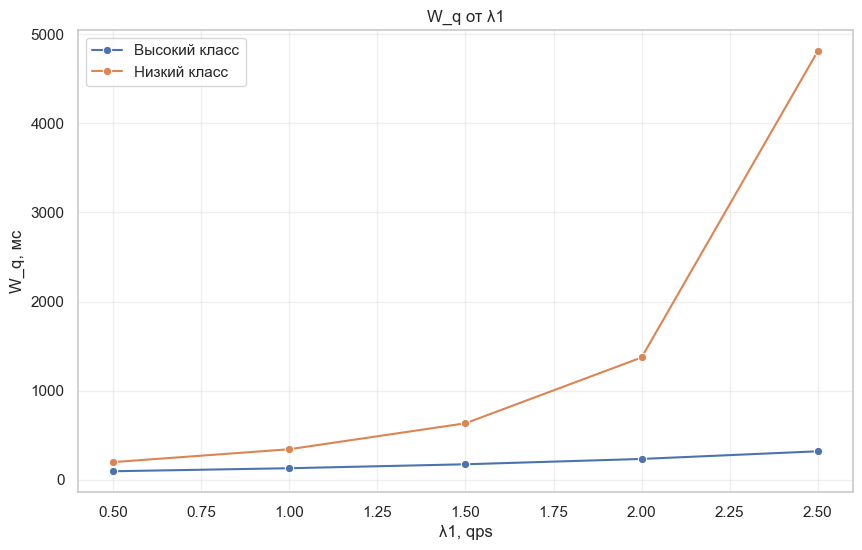

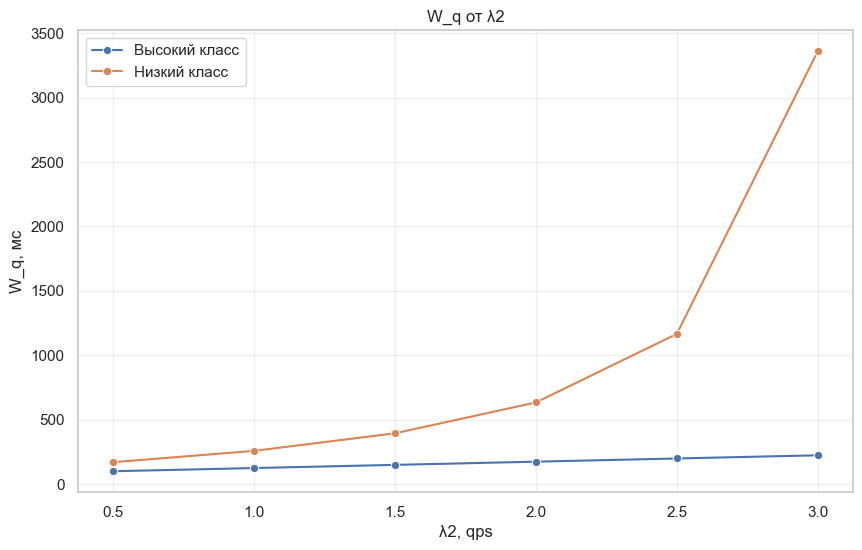

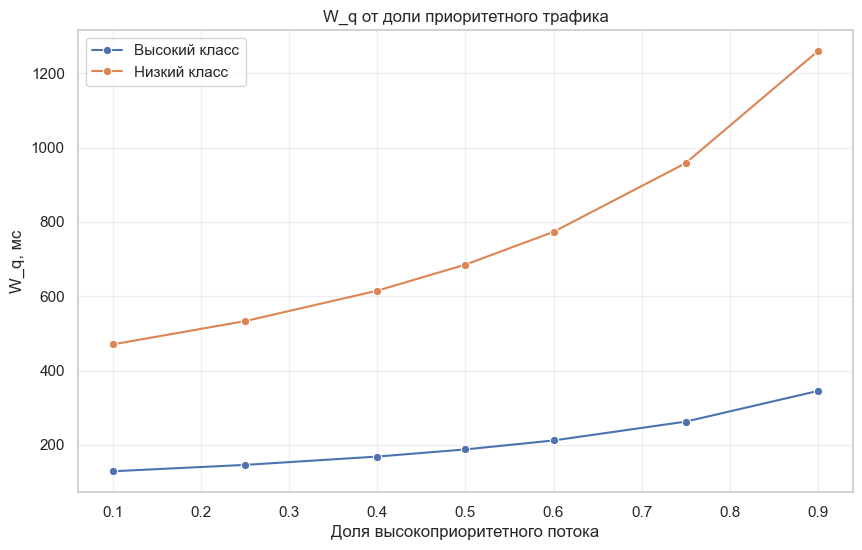

In [16]:
plt.figure()
sns.lineplot(data=priority_experiments, x="lambda_high_qps", y="W_q_high_ms_theory", marker="o", label="Высокий класс")
sns.lineplot(data=priority_experiments, x="lambda_high_qps", y="W_q_low_ms_theory", marker="o", label="Низкий класс")
plt.title("W_q от λ1")
plt.xlabel("λ1, qps")
plt.ylabel("W_q, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure()
sns.lineplot(data=background_experiments, x="lambda_low_qps", y="W_q_high_ms_theory", marker="o", label="Высокий класс")
sns.lineplot(data=background_experiments, x="lambda_low_qps", y="W_q_low_ms_theory", marker="o", label="Низкий класс")
plt.title("W_q от λ2")
plt.xlabel("λ2, qps")
plt.ylabel("W_q, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure()
sns.lineplot(data=mix_experiments, x="high_share", y="W_q_high_ms_theory", marker="o", label="Высокий класс")
sns.lineplot(data=mix_experiments, x="high_share", y="W_q_low_ms_theory", marker="o", label="Низкий класс")
plt.title("W_q от доли приоритетного трафика")
plt.xlabel("Доля высокоприоритетного потока")
plt.ylabel("W_q, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Временная диаграмма занятости по классам


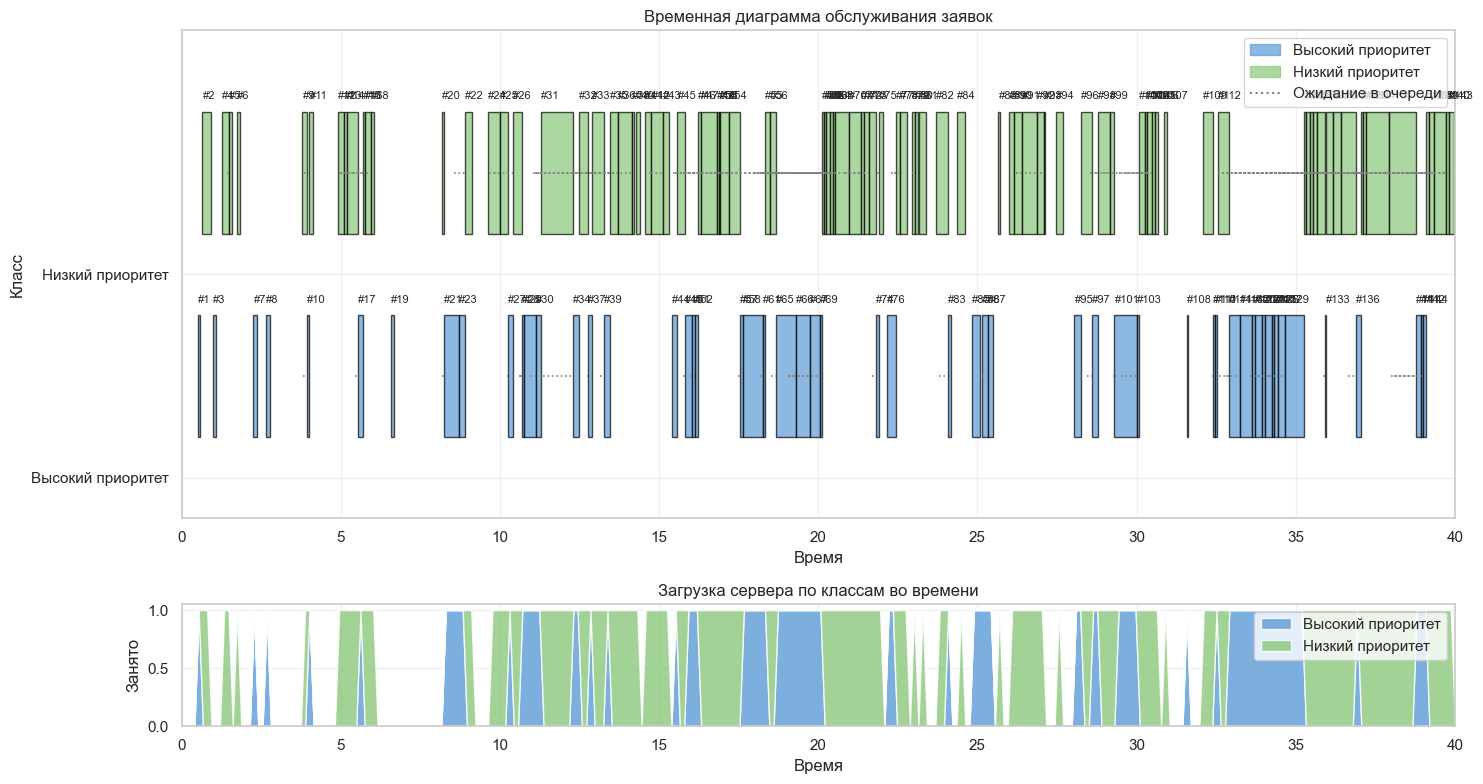

In [17]:
def simulate_priority_mm1_detailed(lambda_high: float, lambda_low: float, mu_rpc: float, mu_resp: float, db_size: int, simulation_time: float, seed: int):
    rng = np.random.default_rng(seed)
    next_arrival_high = rng.exponential(1.0 / lambda_high) if lambda_high > 0 else float("inf")
    next_arrival_low = rng.exponential(1.0 / lambda_low) if lambda_low > 0 else float("inf")
    next_departure = float("inf")
    queue_high = deque()
    queue_low = deque()
    server_busy = False
    current_request = None
    served_requests = []
    request_id = 0

    def start_service(request_info: dict, start_time: float) -> None:
        nonlocal next_departure, server_busy, current_request
        service_time, _ = sample_service_time(mu_rpc, mu_resp, db_size, rng)
        next_departure = start_time + service_time
        server_busy = True
        current_request = {
            "id": request_info["id"],
            "arrival_time": request_info["arrival_time"],
            "start_time": start_time,
            "priority_class": request_info["priority_class"],
            "end_time": next_departure,
            "wait_time": start_time - request_info["arrival_time"],
        }

    while True:
        event_time = min(next_arrival_high, next_arrival_low, next_departure)
        if event_time == float("inf") or event_time > simulation_time:
            break
        if next_arrival_high <= next_arrival_low and next_arrival_high <= next_departure:
            request_id += 1
            incoming = {"id": request_id, "arrival_time": event_time, "priority_class": "high"}
            if server_busy:
                queue_high.append(incoming)
            else:
                start_service(incoming, event_time)
            next_arrival_high = event_time + rng.exponential(1.0 / lambda_high) if lambda_high > 0 else float("inf")
        elif next_arrival_low <= next_departure:
            request_id += 1
            incoming = {"id": request_id, "arrival_time": event_time, "priority_class": "low"}
            if server_busy:
                queue_low.append(incoming)
            else:
                start_service(incoming, event_time)
            next_arrival_low = event_time + rng.exponential(1.0 / lambda_low) if lambda_low > 0 else float("inf")
        else:
            served_requests.append(current_request.copy())
            if queue_high:
                start_service(queue_high.popleft(), event_time)
            elif queue_low:
                start_service(queue_low.popleft(), event_time)
            else:
                server_busy = False
                current_request = None
                next_departure = float("inf")

    return served_requests

detailed_requests = simulate_priority_mm1_detailed(lambda_high_qps, lambda_low_qps, mu_rpc_qps, mu_resp_qps, database_size, 40.0, BASE_SEED + 2026)
timeline_df = pd.DataFrame(detailed_requests)
timeline_df["class_name"] = timeline_df["priority_class"].map({"high": "Высокий приоритет", "low": "Низкий приоритет"})

colors = {"high": "#5B9BD5", "low": "#8BC77B"}
lane_map = {"high": 0, "low": 1}
lane_labels = ["Высокий приоритет", "Низкий приоритет"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), gridspec_kw={"height_ratios": [4, 1]})
for req in detailed_requests:
    lane = lane_map[req["priority_class"]]
    visible_end = min(req["end_time"], 40.0)
    rect = Rectangle(
        (req["start_time"], lane + 0.2),
        visible_end - req["start_time"],
        0.6,
        facecolor=colors[req["priority_class"]],
        edgecolor="black",
        alpha=0.7,
    )
    ax1.add_patch(rect)
    ax1.text(req["start_time"], lane + 0.85, f"#{req['id']}", fontsize=8, ha="left", va="bottom")
    if req["wait_time"] > 1e-12:
        ax1.plot(
            [req["arrival_time"], req["start_time"]],
            [lane + 0.5, lane + 0.5],
            color="gray",
            linestyle=":",
            linewidth=1.2,
        )

ax1.set_xlim(0, 40.0)
ax1.set_ylim(-0.2, 2.2)
ax1.set_yticks(range(2))
ax1.set_yticklabels(lane_labels)
ax1.set_xlabel("Время")
ax1.set_ylabel("Класс")
ax1.set_title("Временная диаграмма обслуживания заявок")
ax1.grid(True, alpha=0.3)
legend_handles = [
    mpatches.Patch(color=colors["high"], label="Высокий приоритет", alpha=0.7),
    mpatches.Patch(color=colors["low"], label="Низкий приоритет", alpha=0.7),
    plt.Line2D([0], [0], color="gray", linestyle=":", label="Ожидание в очереди"),
]
ax1.legend(handles=legend_handles, loc="upper right")

time_grid = np.linspace(0, 40.0, 300)
busy_high = []
busy_low = []
for t in time_grid:
    busy_high.append(
        1 if any(req["priority_class"] == "high" and req["start_time"] <= t <= req["end_time"] for req in detailed_requests) else 0
    )
    busy_low.append(
        1 if any(req["priority_class"] == "low" and req["start_time"] <= t <= req["end_time"] for req in detailed_requests) else 0
    )

ax2.stackplot(
    time_grid,
    busy_high,
    busy_low,
    labels=["Высокий приоритет", "Низкий приоритет"],
    colors=[colors["high"], colors["low"]],
    alpha=0.8,
)
ax2.set_xlim(0, 40.0)
ax2.set_ylim(0, 1.05)
ax2.set_xlabel("Время")
ax2.set_ylabel("Занято")
ax2.set_title("Загрузка сервера по классам во времени")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()


## Контрольные сценарии


In [18]:
scenario_defs = [("Низкая общая нагрузка", 0.6, 1.0), ("Базовый режим", lambda_high_qps, lambda_low_qps), ("Умеренная перегрузка низкого класса", 1.5, 2.7), ("Высокая доля приоритетного трафика", 2.6, 0.8), ("Почти граница устойчивости", 1.8, 2.8)]
rows = []
for label, lam_high, lam_low in scenario_defs:
    theory = theoretical_priority_characteristics(lam_high, lam_low, mu_eff_qps, second_moment)
    sim = aggregate_priority_replications(lam_high, lam_low, mu_rpc_qps, mu_resp_qps, database_size, simulation_time_sec, replications)
    rows.append({"Сценарий": label, "rho_total": theory["rho_total"], "W_q_high_ms_theory": ms(theory["W_q_high"]) if np.isfinite(theory["W_q_high"]) else float("inf"), "W_q_low_ms_theory": ms(theory["W_q_low"]) if np.isfinite(theory["W_q_low"]) else float("inf"), "W_q_high_ms_sim": ms(sim["W_q_high"]), "W_q_low_ms_sim": ms(sim["W_q_low"]), "L_q_high_theory": theory["L_q_high"], "L_q_low_theory": theory["L_q_low"]})
scenario_results = pd.DataFrame(rows)
scenario_results


,Сценарий,rho_total,W_q_high_ms_theory,W_q_low_ms_theory,W_q_high_ms_sim,W_q_low_ms_sim,L_q_high_theory,L_q_low_theory
0,Низкая общая нагрузка,0.331957,62.388098,93.389324,62.132625,92.446376,0.037433,0.093389
1,Базовый режим,0.726156,173.470993,633.465580,171.658780,599.174150,0.260206,1.266931
2,Умеренная перегрузка низкого класса,0.871387,208.165191,1618.535963,206.203118,1509.831821,0.312248,4.370047
3,Высокая доля приоритетного трафика,0.705408,252.016572,855.477535,252.889637,862.107579,0.655243,0.684382
4,Почти граница устойчивости,0.954376,250.639229,5493.576955,243.656737,4753.375599,0.451151,15.382015


## Выводы

1. Абсолютный приоритет без прерывания обслуживания заметно уменьшает ожидание высокого класса.
2. Основная цена этого выигрыша — рост времени ожидания низкоприоритетных заявок.
3. При росте общей нагрузки низкий класс деградирует сильнее, чем высокий.
4. При приближении `ρ` к единице обе очереди растут, но низкий класс теряет качество обслуживания быстрее.
